# Humanoid Sensors and Actuators
## Group 5
| Name | Matr. # | Email |
|------|---------|-------|
| Samuele Ribaudo | 03821248 | samuele.ribaudo@tum.de |
| Hong Yan Jun  | 03813507 | go75kes@mytum.de |
| Alessandro Canalicchio | 03796273 | go73xix@mytum.de |
| Niklas Peter | 03812287 | n.peter@tum.de |
| Emile Gebrael | 03812968 | emile.gebrael@tum.de |

# Tutorial 5

Course Instructor: Dr.-Ing. J. Rogelio Guadarrama Olvera
hsa-lecture.ics@xcit.tum.de

Summer Semester 2026

## Notebook Setup

1. Open the VS Code terminal.
2. Create the virtual environment: `python -m venv .venv`
3. Activate it:
* **Mac/Linux:** `source .venv/bin/activate`
* **Windows:** `.\.venv\Scripts\activate`
4. Go to code directory `cd T5/code/`
5. Install dependencies: `pip install -r requirements.txt`

6. Set the Notebook Kernel: Click **Select Kernel** in the top right -> **Python Environments** -> Choose **.venv**.

Run the following code block to import all the required libraries. 

In [62]:
import numpy as np
import matplotlib.pyplot as plt

## Acoustic Sensors and Signal Processing (57 points)

In this tutorial we will refresh some basics of signal processing including correlation, Fast Fourier Transform (FFT) and filtering. All tasks are solvable with Python, Matlab, Octave or Scilab with a slightly varying syntax.

**Note:** You may use any of the above programming languages. However, we strongly recommend using Jupyter Notebooks (python) to solve and visualize all the tutorial. We will only support installation/setup questions related to python.

## 1 Sound Source Localization (8 points)

### Report

**R.1.1 (3 points)** Find the expression to determine the azimuth angle of a sound source for a system with two microphones. Derive the equations shown in the slides of Lecture 3 step by step.

Type here the answer...



**R.1.2 (3 points)** Find the expression to determine the velocity of a target from the pulse duration difference of a radar sensor. Derive the equations shown in the slides of Lecture 3 step by step.




Type here the answer...




**R.1.3 (1 point)** How can we measure the distance to a target?




Type here the answer...




**R.1.4 (1 point)** How can we measure the speed of a moving target?




Type here the answer...




## 2 Fast Fourier Transform (8 points)

### Tasks

**T.2.1** Create a signal consisting of the sum of two sine waves using a sample frequency of 1000Hz, one with amplitude of 1 and frequency of 50 Hz and the other with amplitude 0.5 and frequency 120 Hz. Plot the signal over a time slot of 2s.




In [63]:
# type here the code...



**T.2.2** Run a FFT (Fast Fourier transform) on the signal from T.2.1 and plot it. Normalize the output to 1 and only show positive frequencies.




In [64]:
# type here the code...



**T.2.3** Add random noise to the signal from T.2.1 and plot the signal again.




In [65]:
# type here the code...



**T.2.4** Run the FFT on the noisy signal from T.2.3 and plot it.




In [66]:
# type here the code...



### Report

**R2.1 (2 points)** Is it possible to implement FFT to an online data streaming? Why?




Type here the answer...




**R2.2 (2 points)** How can you use FFT in signal processing?




Type here the answer...




**R2.3 (2 points)** Deliver the code used to generate the signals and plots?




Type here the code...





## 3 Audio Correlation (8 points)

### Tasks

**T.3.1** Load the ‘chimes.wav’ file into the workspace and isolate one of its channels.

- Plot the signal with a reasonable time scale.
- If you have speakers/headphones: try to output the audio signal.




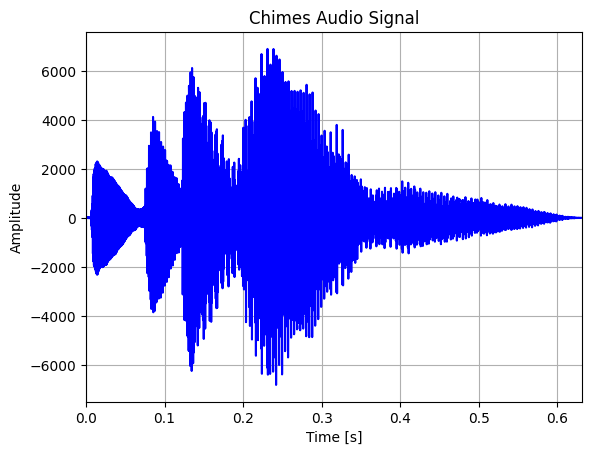

In [67]:
### IMPORT THE AUDIO FILE ###
from scipy.io import wavfile

# Load the audio file
sample_rate, data = wavfile.read('../audio/chimes.wav')

# Isolate one channel
if len(data.shape) > 1:
    signal = data[:, 0] # Left channel
else:
    signal = data       # Already mono

### PLOT THE AUDIO SIGNAL ###
time = np.arange(len(signal)) / sample_rate

plt.plot(time, signal, color='b')
plt.title('Chimes Audio Signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, time[-1])  # Limits the x-axis to the exact length of the audio
plt.show()


**T.3.2** Run an FFT on the audio signal from T.3.1 and plot it.




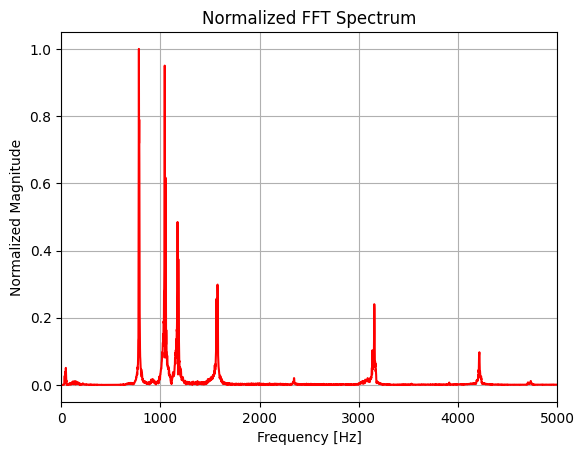

In [68]:
### RUN THE FFT ###
n = len(signal)

fft_output = np.fft.fft(signal)

frequencies = np.fft.fftfreq(n, 1 / sample_rate) # Calculate the frequencies corresponding to the FFT points
magnitude = np.abs(fft_output) # Take the absolute value to get the magnitude spectrum
magnitude_normalized = magnitude / np.max(magnitude) # Normalize the output to 1
# Filter out only the positive frequencies
positive_frequencies = frequencies[:n // 2]
positive_magnitude = magnitude_normalized[:n // 2]

### PLOT THE FFT SPECTRUM ###
plt.plot(positive_frequencies, positive_magnitude, color='r')
plt.title('Normalized FFT Spectrum')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Normalized Magnitude')
plt.grid(True)
plt.xlim(0, 5000)  # Zoomed into 0-5kHz where most audio frequencies lie
plt.show()


**T.3.3** Generate a left and a right channel from the signal of T.3.1 and add a delay and scaling factor to one of them. Make the delay and scaling factors variable.




In [69]:
delay = 0.01  # seconds
scaling_factor = 0.7

# Convert the time delay into the number of discrete samples
delay_samples = int(delay * sample_rate)

# Left channel: Pad with zeros at the end
left_channel = np.pad(signal, (0, delay_samples), mode='constant')
# Right channel: Pad with zeros at the start
right_channel = np.pad(signal, (delay_samples, 0), mode='constant') * scaling_factor



**T.3.4** Plot the two signals in the same figure.




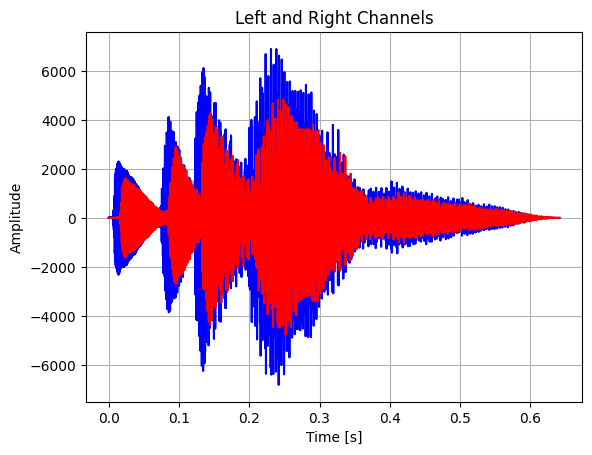

In [70]:
time_padded = np.arange(len(left_channel)) / sample_rate

# Plot both signals together
plt.plot(time_padded, left_channel, label='Left Channel', color='b')
plt.plot(time_padded, right_channel, label='Right Channel', color='r')

plt.title('Left and Right Channels')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

**T.3.5** If you have speakers/headphones: listen to the signals and find parameters at which stereo localization works for you.




In [71]:
# Stack channels vertically to create a stereo layout (2, N) and transpose to (N, 2)
stereo_signal = np.vstack((left_channel, right_channel)).T

# Ensure the data type is correct for audio playback (16-bit PCM integer)
if stereo_signal.dtype != np.int16:
    stereo_signal = (stereo_signal / np.max(np.abs(stereo_signal)) * 32767).astype(np.int16)

# Save the file into the audio directory with the delay value in the name
filename = f'../audio/chimes_stereo_{delay}.wav'
wavfile.write(filename, sample_rate, stereo_signal)



**T.3.6** Run cross-correlation on both signals and plot the correlation against delay.




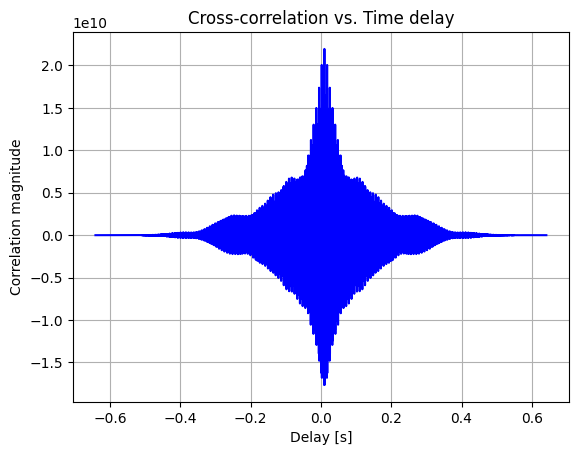

True physical delay configured: 0.01 seconds
Delay estimated by cross-correlation peak: 0.009977324263038548 seconds


In [72]:
cross_corr = np.correlate(right_channel, left_channel, mode='full')

num_lags = len(cross_corr)
lags_samples = np.arange(-num_lags // 2 + 1, num_lags // 2 + 1)

lags_seconds = lags_samples / sample_rate # Convert sample lags into time delays (seconds)

plt.plot(lags_seconds, cross_corr, color='b')
plt.title('Cross-correlation vs. Time delay')
plt.xlabel('Delay [s]')
plt.ylabel('Correlation magnitude')
plt.grid(True)
plt.show()

# Find and print the peak location
estimated_delay = lags_seconds[np.argmax(cross_corr)]
print(f"True physical delay configured: {delay} seconds")
print(f"Delay estimated by cross-correlation peak: {estimated_delay} seconds")


**T.3.7** Add noise with a normal distribution to both channels.




In [73]:
noise_level = 1000.0  

left_noise = np.random.normal(0, noise_level, size=left_channel.shape)
right_noise = np.random.normal(0, noise_level, size=right_channel.shape)

left_channel_noisy = left_channel + left_noise
right_channel_noisy = right_channel + right_noise



**T.3.8** Run cross-correlation on the noisy signals and plot.




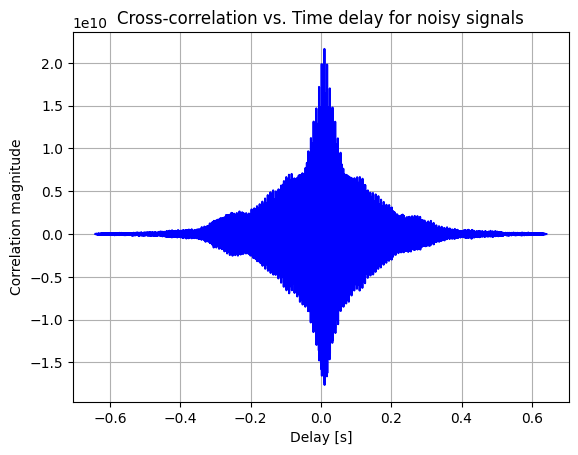

True physical delay configured: 0.01 seconds
Delay estimated by noisy cross-correlation peak: 0.009977324263038548 seconds


In [74]:
cross_corr_noisy = np.correlate(right_channel_noisy, left_channel_noisy, mode='full')

num_lags_noisy = len(cross_corr_noisy)
lags_samples_noisy = np.arange(-num_lags_noisy // 2 + 1, num_lags_noisy // 2 + 1)

lags_seconds_noisy = lags_samples_noisy / sample_rate # Convert sample lags into time delays (seconds)

plt.plot(lags_seconds_noisy, cross_corr_noisy, color='b')
plt.title('Cross-correlation vs. Time delay for noisy signals')
plt.xlabel('Delay [s]')
plt.ylabel('Correlation magnitude')
plt.grid(True)
plt.show()

# Find and print the peak location
estimated_delay_noisy = lags_seconds_noisy[np.argmax(cross_corr_noisy)]
print(f"True physical delay configured: {delay} seconds")
print(f"Delay estimated by noisy cross-correlation peak: {estimated_delay_noisy} seconds")

### Report

**R.3.1 (2 point)** Is it possible to implement the cross-correlation to an online data streaming? Why?




No. An online data stream runs forever. If we try to run a standard cross-correlation on it continuously, the size of our data arrays grows infinitely, becoming a computationally challenging problem.



**R.3.2 (2 point)** If you answered “no” to R.3.1, how would you work around to use it to identify the interaural time delay?




A work around would be to use a sliding window approach: first we divide the continuous incoming audio stream into small buffers of fixed size, then we run the cross correlation only on these slices of data.



**R.3.3 (4 points)** Deliver the code to generate the signals and the plots (T.3.1 - T.3.8).






## 4 Signal Filtering (33 points)

### Tasks

**T.4.1** Create a signal consisting of two sine waves, one with amplitude of 1 and a frequency of 50 Hz and one with amplitude 0.5 and frequency of 500 Hz using a sample frequency of 10,000 Hz.




In [75]:
# type here the code...





**T.4.2** Plot the signal over a time slot of 0.1s.




In [76]:
# type here the code...



**T.4.3** Design an analog low-pass passive filter with a cut-off frequency of 50 Hz.




Type here the answer...




**T.4.4** Design and implement a first order discrete low-pass filter with cut-off frequency of 50 Hz.




In [77]:
# type here the code...





**T.4.5** Apply the filter from T.4.4 to the signal created in T.4.1. Plot again the signal after filtering.




In [78]:
# type here the code...




**T.4.6** Design an analog high-pass passive filter with a cut-off frequency of 500 Hz.




Type here the answer...




**T.4.7** Design and implement a first order discrete high-pass filter with cut-off frequency of 500 Hz.




In [79]:
# type here the code...





**T.4.8** Apply the filter from T.4.7 to the signal created in T.4.1. Plot again the signal after filtering.




In [80]:
# type here the code...



**T.4.9** Create another sine wave signal with a frequency of 1,000 Hz using a sample frequency of 10,000 Hz. Then, add it to the signal created in T.4.1.




In [81]:
# type here the code...





**T.4.10** Design an analog band-pass active filter to recover the 500 Hz signal.




Type here the answer...




**T.4.11** Design and implement a discrete band-pass filter to recover the 500 Hz signal from the superposed signal.




In [82]:
# type here the code...





**T.4.12** Apply the filter from T.4.11 to the signal created in T.4.9. Plot again the signal after filtering.




In [83]:
# type here the code...



### Report

**R.4.1 (2 points)** Detail the design process of the filter in T.4.3. Draw the required circuit and calculate the value for the components step by step.




Type here the answer...


**R.4.2 (2 points)** Detail the design process of the filter in T.4.4. Derive the equation to implement the filter step by step on a data stream.




Type here the answer...




**R.4.3 (2 points)** Detail the design process of the filter in T.4.6. Draw the required circuit and calculate the value for the components step by step.




Type here the answer...


**R.4.4 (2 points)** Detail the design process of the filter in T.4.7. Derive the equation to implement the filter step by step on a data stream.




Type here the answer...




**R.4.5 (2 points)** Detail the design process of the filter in T.4.10. Draw the required circuit and calculate the value for the components step by step.




Type here the answer...



**R.4.6 (2 points)** Detail the design process of the filter in T.4.11. Derive the equation to implement the filter step by step on a data stream.




Type here the answer...




**R.4.7 (2 point)** What is the difference between passive and active filters?




Type here the answer...




**R.4.8 (2 point)** What is the difference between FIR and IIR filters?




Type here the answer...




**R.4.9 (2 point)** What is the “order” of a discrete filter?




Type here the answer...




**R.4.10 (2 point)** How could you implement a continuous-time filter in a robotic system?




Type here the answer...




**R.4.11 (2 point)** How could you implement a discrete-time filter in a robotic system?




Type here the answer...




**R.4.12 (3 point)** What are the advantages and disadvantages of analog and digital filters in robotic systems?




Type here the answer...




**R.4.13 (2 point)** Is it possible to make a 1000 Hz Low-Pass filter in a digital system with a sampling rate of 1000 Hz?




Type here the answer...




**R.4.14 (6 points)** Deliver the code to generate the signals and the plots (T.4.1 - T.4.12).


